<a href="https://colab.research.google.com/github/ElMartinez31/Data_Science/blob/main/Projects/Classical_Frameworks/Fashion_MNIST_image_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## technics to augment data!

### VOICE
# Pitch shift
# adding noise
# removing "empty speech parts"
# adding volume (+db,-db)

###IMAGE
# Tilting (vertical, horizontal)
# Blurring
# Adding nosie
# Zoom (in/out)

# ==> very important technics to increase out dataset

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # deep learning
from keras.datasets import fashion_mnist # keras = wrapper using tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
import keras


In [2]:
# import os

# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("zalando-research/fashionmnist")

# print("Path to dataset files:", path)

# print(os.listdir(path))

['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [6]:
# path_train_df = path + '/' + 'fashion-mnist_train.csv'
# df_train = pd.read_csv(path_train_df)
# df_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# global variables

num_classes = 10
batch_size = 64
epochs = 20

img_row, img_col = 28,28 # standard resolution of our imgs

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()



In [12]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [14]:
X_train.shape #(60000, 28, 28)

(60000, 28, 28)

In [15]:
y_train.shape

(60000,)

In [30]:
# now let's reshape the 1D data to 2D

X_train = X_train.reshape(X_train.shape[0], img_row, img_col, 1)
X_test = X_test.reshape(X_test.shape[0], img_row, img_col, 1)
input_shape = (img_row, img_col, 1)



In [17]:
# standardize data

X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

In [19]:
# check
X_train[X_train != 0]


array([0.00392157, 0.05098039, 0.28627452, ..., 0.16470589, 0.08235294,
       0.07058824], dtype=float32)

In [20]:
# one hot encode the lables
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [21]:
# check
y_train[0:2] #ok

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [ ]:
##### Model implementation (CNN) ########


In [28]:
# instantitate
model = Sequential()


In [32]:
# Build CNN

model.add(Conv2D(32, kernel_size = (3,3), activation = "relu", input_shape= input_shape)) # learns global shapes, 32 filters (can be optimized)
model.add(MaxPooling2D(pool_size = (2,2))) # size reduction
model.add(Conv2D(32, kernel_size = (3,3), activation = "relu")) # learns ùmore detailed shapes
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Flatten()) # back to 1D
model.add(Dense(128, activation = "relu")) # get evereything "together"
model.add(Dense(64, activation ="relu")) # same but as another "abstraction" layer
model.add(Dropout(0.5)) # regularization
model.add(Dense(num_classes, activation="softmax")) # 10 classes => softmax


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# Formule générale pour la taille de sortie d’une convolution 2D

# Soit une entrée de taille :
# (h, w, c), ici (28,28,1)

# Et une couche :
# Conv2D(filters=F, kernel_size=(k_h, k_w), strides=(s_h, s_w), padding="same" ou "valid") => le padding permet d'adapter le bord de l'image pour ne pas perde de pixel

# Alors :

# h_out = (h + 2*p_h - k_h) / s_h + 1
# w_out = (w + 2*p_w - k_w) / s_w + 1


# p_h, p_w = taille du padding (haut/bas et gauche/droite)

# k_h, k_w = taille du filtre (kernel)

# s_h, s_w = stride (pas de déplacement)

# F = nombre de filtres (→ donne la profondeur de la sortie)

# 📦 Deux cas principaux dans Keras / TensorFlow
# 1. padding="valid" → sans padding

# Aucune bordure ajoutée → la sortie est plus petite :

# h_out = floor((h - k_h) / s_h + 1)
# w_out = floor((w - k_w) / s_w + 1)


# Exemple :
# Entrée : (32, 32, 3)
# Conv2D(32, (3,3), strides=(1,1), padding="valid")

# h_out = 32 - 3 + 1 = 30
# w_out = 32 - 3 + 1 = 30


# Sortie : (30, 30, 32)

# 2. padding="same" → avec padding automatique

# Le padding est ajouté pour garder la même taille (si stride=1) :

# h_out = ceil(h / s_h)
# w_out = ceil(w / s_w)


# Exemple :
# Entrée : (32, 32, 3)
# Conv2D(32, (3,3), strides=(1,1), padding="same")

# h_out = 32
# w_out = 32


# Sortie : (32, 32, 32)

# ⚙️ Et pour MaxPooling2D

# Le pooling réduit la taille selon pool_size et stride :

# h_out = h / stride_h
# w_out = w / stride_w


# Exemple :
# MaxPooling2D(pool_size=(2,2)) divise la hauteur et la largeur par 2.

# 🔎 Résumé
# Paramètre	Effet
# kernel_size	Taille du filtre → influence la réduction spatiale
# stride	Plus grand stride = sortie plus petite
# padding="same"	Conserve la taille
# padding="valid"	Réduit la taille
# filters	Définit la profondeur (nb de feature maps)



# in fine:

# Tu obtiens 32 images ("feature maps") de taille 32x32 chacune,
# chacune étant la sortie d’un filtre différent.

# Chaque filtre (kernel) apprend à détecter un motif particulier, par exemple :

# des bords verticaux,

# des bords horizontaux,

# des coins,

# des textures spécifiques,

# ou même, plus tard, des formes complexes (yeux, roues, etc., selon les données).

In [40]:
# compile model with adam optim, categorical_croosE as loss

model.compile(loss = keras.losses.categorical_crossentropy,
              optimizer = keras.optimizers.Adam(),
              metrics = ["accuracy"])

#train model and test/validate the mode with test data after each epoch through training data
# get histopry of loss and accuracy for each epoch

hist = model.fit(X_train, y_train,
                 batch_size = batch_size,
                 epochs = 7,
                 verbose = 1,
                 validation_data = (X_test, y_test)) # used at the end at each epoch to check the accuracy on unseen data

Epoch 1/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 55ms/step - accuracy: 0.9191 - loss: 0.2235 - val_accuracy: 0.9051 - val_loss: 0.2750
Epoch 2/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.9267 - loss: 0.2035 - val_accuracy: 0.8997 - val_loss: 0.2763
Epoch 3/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 47ms/step - accuracy: 0.9285 - loss: 0.1956 - val_accuracy: 0.9082 - val_loss: 0.2694
Epoch 4/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.9345 - loss: 0.1838 - val_accuracy: 0.9064 - val_loss: 0.2673
Epoch 5/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.9388 - loss: 0.1709 - val_accuracy: 0.9110 - val_loss: 0.2655
Epoch 6/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 54ms/step - accuracy: 0.9413 - loss: 0.1608 - val_accuracy: 0.9099 - val_loss: 0.2737
Epoch 7/7
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.9441 - loss: 0.1521 - val_accuracy: 0.9086 - val_loss: 0.3083


In [57]:
# final score
score = model.evaluate(X_test, y_test)
print(f"loss : {score[0]} accuracy: {score[1]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9114 - loss: 0.2990
loss : 0.3082684576511383 accuracy: 0.9085999727249146


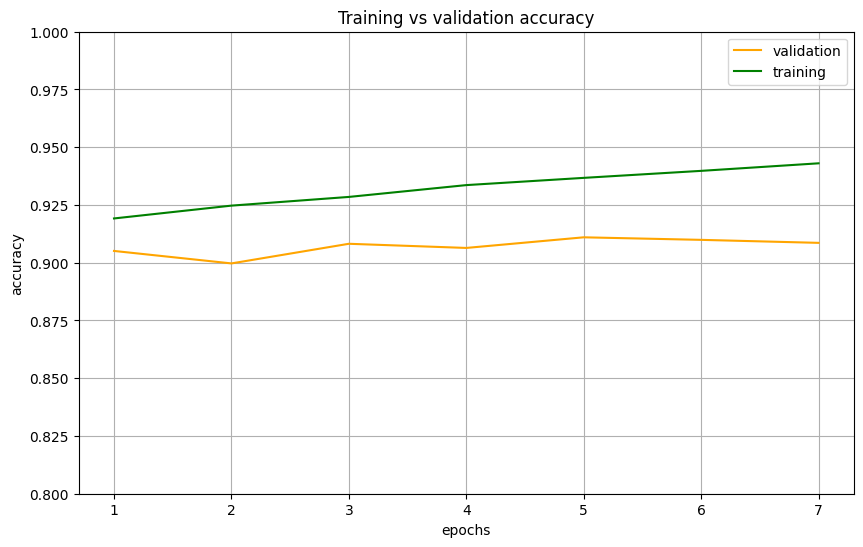

In [65]:
# plot results
import importlib
import matplotlib.pyplot as plt
importlib.reload(plt)  # remet les fonctions d’origine
nb_epochs = len(hist.history["accuracy"]) # nb epoch
range_epochs = list(range(1, nb_epochs + 1)) #range (1,b) = 1..(b-1)


plt.figure(figsize = (10,6))
plt.plot(range_epochs, hist.history["val_accuracy"], color = "orange", label = "validation")
plt.plot(range_epochs, hist.history["accuracy"] , color = "green", label = "training")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("Training vs validation accuracy")
plt.legend()
plt.grid()
plt.ylim(0.8, 1)
plt.show()

In [59]:
# model summary
model.summary()

# Model: "sequential_1"
# ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
# ┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
# ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
# │ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │ as we saw befiore, we have specified no stride, so (26,26) - (3,3) + (1,1) = 26,26 => shape of output convolution (26,26,32)
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │ dividing by 2 the shape (cuase pooling of (2,2))
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │ same idea
# ├─────────────────────────────────┼────────────────────────┼───────────────
# │ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │ same idea
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ flatten (Flatten)               │ (None, 800)            │             0 │ 5x5x32 (flattening all)
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ dense (Dense)                   │ (None, 128)            │       102,528 │ connect 800 to 128 (arbitrary)
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ dense_1 (Dense)                 │ (None, 64)             │         8,256 │ same idea
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ dropout (Dropout)               │ (None, 64)             │             0 │
# ├─────────────────────────────────┼────────────────────────┼───────────────┤
# │ dense_2 (Dense)                 │ (None, 10)             │           650 │ # output (64 -> 10)
# └─────────────────────────────────┴────────────────────────┴───────────────┘


# for the number of paramters:
# (shape of width of filter x shape of height x number of filter in previous layer + 1) x nb of filters = (3x3x1 +1) x 32 = 320 (for first layer)
# 3rd layer (2nd convolutiuon) : (3x3x32+1)x32 = 289x32 = 9248 => OK

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,008 (1.38 MB)

 Trainable params: 121,002 (472.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 242,006 (945.34 KB)

In [68]:
289*32

9248